In [1]:
import pandas as pd
import numpy as np
import os

# Labelling the Prepared Data
# Labelling Only 1 Dataset 2023 at first

In [261]:
filepath=os.path.join("CWTS+Datasets", "TOTAL_scimagojr 2023.csv")
df=pd.read_csv(filepath, encoding="utf-8")

In [125]:
publishers=df["Publisher"]

In [126]:
len(publishers)

27107

In [217]:
Labels=pd.read_csv("Labels_2023.csv") #see Section: Additional: Steps needed to create the Labels_2023.csv (but for now just skip it and import the labels)

### Add Google Scholar's list GOOD!

In [58]:
df["Title"][0]

'Ca-A Cancer Journal for Clinicians'

In [53]:
Labels.isna().sum()

Labels    20655
dtype: int64

In [231]:
with open("Google Scholar's list.txt", "r") as file1:
    data=file1.read().splitlines()
    for entry in data:
        entry=entry[:-7].strip()
        for j in range(df["Title"].shape[0]):
            if (entry == df["Title"][j]) and (math.isnan(Labels.iloc[j,0])):
                Labels.iloc[j,0]=1

## Add more 0's based on DOAJ index + Manually specified metrics

### (DO not run, too much time) checkDOAJ #taken from the DOAJ index in "Steps needed"


#### DO not RUN

In [5]:
with open("journalcsv__doaj_20250501_1827_utf8.csv","r",encoding="utf-8") as file1:
    title=pd.read_csv(file1)["Journal title"]
def checkDOAJ(name):
    if title.str.contains(name).any():
        return True
    else:
        return False

In [6]:
DOAJ_check=[]
for name in df.Title:
    try:
        DOAJ_check.append(checkDOAJ(name))
    except:
        print(name)
        DOAJ_check.append(False)


C:\Users\User\AppData\Local\Temp\ipykernel_864\4053327238.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if title.str.contains(name).any():


sub\urban


In [65]:
import pandas as pd
DOAJ_check=pd.DataFrame(DOAJ_check)
DOAJ_check.to_csv("DOAJ_check.csv", index=False)

#### Doaj check READ

In [233]:
DOAJ_check=pd.read_csv("DOAJ_check.csv")

### manually FIND SPECIFIC metrics:
- SJR<0.15
- H index < 10
- not in DOAJ (DOAJ_check Dataframe - it's later indexed in not_labeled)
- Self-Cites/Total Cites (3years) >0.4
- Uncited Docs./Total Docs. (3years) > 0.95
- Cites / Doc. (2years) <0.001

not_labeled[((not_labeled["Self-Cites/Total Cites (3years)"] > 0.7) & (not_labeled["H index"] < 10) ) | ((not_labeled.SJR < 0.2) & (not_labeled["H index"] < 15) & (not_labeled["Uncited Docs./Total Docs. (3years)"] > 0.75) & (not_labeled["Cites / Doc. (2years)"] < 0.3))]



In [234]:
not_labeled=df[(Labels.Labels.isna()) & (DOAJ_check.iloc[:,0]==False)]

In [235]:
not_labeled[not_labeled["Uncited Docs./Total Docs. (3years)"]>0.93]

,Title,SJR,H index,IPP,SNIP,Total Docs. (2023),Total Docs. (3years),Total Refs.,Est. value (USD) (2023),Total Cites (3years),Self-Cites/Total Cites (3years),Uncited Docs./Total Docs. (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Coverage_Duration,Publisher,Labels
17836,Sportverletzung-Sportschaden,0.233,25,0.535211,0.194605,70,270,260,1157797.0,36,0.027778,0.937037,89,0.15,3.71,38,Georg Thieme Verlag,1.0
19208,Transactions of the Historic Society of Lancas...,0.203,3,0.076923,0.660000,10,30,708,114072.0,3,0.000000,0.966667,27,0.14,70.80,21,Liverpool University Press,0.0
19210,Actualidad Juridica Iberoamericana,0.202,4,0.059633,0.210105,115,579,4962,1661453.0,43,0.209302,0.930915,576,0.07,43.15,6,Ibero-American Law Institute,0.0
19794,Revista Brasileira de Ciencias Policiais,0.192,2,0.063158,0.195727,38,116,1550,203975.0,9,0.888889,0.939655,106,0.07,40.79,5,National Police Academy,0.0
19863,Revue Francaise de Psychanalyse,0.191,17,0.017730,0.148858,123,335,1563,1464739.0,18,0.444444,0.949254,313,0.04,12.71,53,Presses Universitaires de France,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27097,Trabajo y Derecho,0.100,4,0.017241,0.043912,152,421,1179,1506200.0,11,0.090909,0.976247,322,0.02,7.76,11,"LA LEY Soluciones Legales, S.A.",0.0
27100,Vox Romanica,0.100,5,0.020408,0.122449,29,62,567,223708.0,4,0.000000,0.935484,61,0.02,19.55,13,Francke Verlag,0.0
27101,Waiguo Yuyan yu Wenhua,0.100,2,0.009259,0.048611,41,168,798,200506.0,1,0.000000,0.994048,167,0.00,19.46,6,Hunan Normal University Press,0.0
27103,Zeitschrift fur Deutsches Altertum und Deutsch...,0.100,6,0.017544,0.242105,29,58,1542,228479.0,4,0.000000,0.948276,57,0.10,53.17,25,Franz Steiner Verlag GmbH,0.0


In [236]:
Labels.isna().sum()

Labels    20608
dtype: int64

In [237]:
not_labeled[(not_labeled["Ref. / Doc."]>100) & (not_labeled["Uncited Docs./Total Docs. (3years)"]>0.7)]

,Title,SJR,H index,IPP,SNIP,Total Docs. (2023),Total Docs. (3years),Total Refs.,Est. value (USD) (2023),Total Cites (3years),Self-Cites/Total Cites (3years),Uncited Docs./Total Docs. (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Coverage_Duration,Publisher,Labels
11825,Harvard Civil Rights-Civil Liberties Law Review,0.438,32,0.534884,0.506478,18,45,4200,198281.0,35,0.028571,0.711111,43,0.29,233.33,36,Harvard University Law School,0.0
15625,Denver Law Review,0.289,22,0.333333,0.617495,33,66,7906,278240.0,33,0.090909,0.742424,66,0.51,239.58,9,University of Denver Sturm College of Law,0.0
17585,Early China,0.238,6,0.314286,1.302428,10,38,1066,131109.0,12,0.000000,0.710526,35,0.25,106.60,9,Cambridge University Press,0.0
18718,Uniform Law Review,0.213,15,0.361111,1.601595,35,76,4025,358480.0,33,0.121212,0.776316,75,0.36,115.00,28,Oxford University Press,0.0
18754,Melbourne University Law Review,0.212,21,0.181818,0.234657,20,52,4683,255679.0,20,0.350000,0.711538,52,0.38,234.15,25,Melbourne University Law Review,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26852,Western Historical Quarterly,0.101,15,0.095238,0.700510,10,46,1043,156297.0,7,0.000000,0.826087,45,0.06,104.30,29,Oxford University Press,0.0
26856,Yearbook of Langland Studies,0.101,3,0.055556,0.500000,4,27,455,30558.0,7,0.000000,0.777778,27,0.50,113.75,5,Brepols Publishers,0.0
26862,Zeitschrift fur Historische Forschung,0.101,12,0.033333,0.275000,8,30,826,97765.0,4,0.250000,0.866667,30,0.05,103.25,25,Duncker und Humblot GmbH,0.0
27040,Revista de Historiografia,0.100,9,0.074074,0.163722,16,86,1754,307930.0,11,0.000000,0.895349,83,0.14,109.63,13,Universidad Carlos III de Madrid,0.0


In [238]:
Bad_not_label=not_labeled[(not_labeled.SJR < 0.3) & (not_labeled["H index"] < 10) & ((not_labeled["IPP"] < 0.1) | (not_labeled["Cites / Doc. (2years)"] < 0.25) | ((not_labeled["Self-Cites/Total Cites (3years)"] > 0.8) & (not_labeled["Total Docs. (3years)"] > 50) ) | (not_labeled["SNIP"] < 0.1)) | ((not_labeled["Ref. / Doc."]>100) & (not_labeled["Uncited Docs./Total Docs. (3years)"]>0.8))]

In [134]:
Bad_not_label

,Title,SJR,H index,IPP,SNIP,Total Docs. (2023),Total Docs. (3years),Total Refs.,Est. value (USD) (2023),Total Cites (3years),Self-Cites/Total Cites (3years),Uncited Docs./Total Docs. (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Coverage_Duration,Publisher
15321,Eminak,0.299,5,0.175926,0.520780,64,217,1778,277838.0,46,0.260870,0.843318,216,0.23,27.78,6,"Scientific Research Centre Lukomorie"""""
15607,Janus. Estudios Sobre El Siglo De Oro,0.290,3,0.142857,0.646017,24,72,935,111240.0,13,0.076923,0.833333,72,0.16,38.96,6,Universidade da Coruna
15686,Revista Arheologica,0.288,4,0.176471,0.397466,19,60,576,254375.0,12,0.000000,0.850000,60,0.24,30.32,8,Institute of Cultural Heritage of the Academy ...
15880,Modern History of Russia,0.282,7,0.135000,0.800501,68,201,1611,859082.0,38,0.315789,0.865672,201,0.18,23.69,10,Saint Petersburg State University
15919,Vestnik Tomskogo Gosudarstvennogo Universiteta...,0.281,8,0.188552,0.679625,90,298,2513,1237895.0,64,0.281250,0.828859,298,0.23,27.92,10,Tomsk State University
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27100,Vox Romanica,0.100,5,0.020408,0.122449,29,62,567,223708.0,4,0.000000,0.935484,61,0.02,19.55,13,Francke Verlag
27101,Waiguo Yuyan yu Wenhua,0.100,2,0.009259,0.048611,41,168,798,200506.0,1,0.000000,0.994048,167,0.00,19.46,6,Hunan Normal University Press
27103,Zeitschrift fur Deutsches Altertum und Deutsch...,0.100,6,0.017544,0.242105,29,58,1542,228479.0,4,0.000000,0.948276,57,0.10,53.17,25,Franz Steiner Verlag GmbH
27104,Zeitschrift fur Kunstgeschichte,0.100,9,0.182446,0.312859,22,68,965,246409.0,5,0.000000,0.926471,66,0.07,43.86,26,Deutscher Kunstverlag GmbH


In [135]:
Labels.Labels.isna()

0         True
1         True
2         True
3         True
4         True
         ...  
27102    False
27103     True
27104     True
27105     True
27106     True
Name: Labels, Length: 27107, dtype: bool

In [31]:
Labels.Labels.isna().sum()

16808

### Label the chosen as 0

In [239]:
for inde in Bad_not_label.index:
    Labels.iloc[inde,0]=0

In [137]:
Bad_not_label

,Title,SJR,H index,IPP,SNIP,Total Docs. (2023),Total Docs. (3years),Total Refs.,Est. value (USD) (2023),Total Cites (3years),Self-Cites/Total Cites (3years),Uncited Docs./Total Docs. (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Coverage_Duration,Publisher
15321,Eminak,0.299,5,0.175926,0.520780,64,217,1778,277838.0,46,0.260870,0.843318,216,0.23,27.78,6,"Scientific Research Centre Lukomorie"""""
15607,Janus. Estudios Sobre El Siglo De Oro,0.290,3,0.142857,0.646017,24,72,935,111240.0,13,0.076923,0.833333,72,0.16,38.96,6,Universidade da Coruna
15686,Revista Arheologica,0.288,4,0.176471,0.397466,19,60,576,254375.0,12,0.000000,0.850000,60,0.24,30.32,8,Institute of Cultural Heritage of the Academy ...
15880,Modern History of Russia,0.282,7,0.135000,0.800501,68,201,1611,859082.0,38,0.315789,0.865672,201,0.18,23.69,10,Saint Petersburg State University
15919,Vestnik Tomskogo Gosudarstvennogo Universiteta...,0.281,8,0.188552,0.679625,90,298,2513,1237895.0,64,0.281250,0.828859,298,0.23,27.92,10,Tomsk State University
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27100,Vox Romanica,0.100,5,0.020408,0.122449,29,62,567,223708.0,4,0.000000,0.935484,61,0.02,19.55,13,Francke Verlag
27101,Waiguo Yuyan yu Wenhua,0.100,2,0.009259,0.048611,41,168,798,200506.0,1,0.000000,0.994048,167,0.00,19.46,6,Hunan Normal University Press
27103,Zeitschrift fur Deutsches Altertum und Deutsch...,0.100,6,0.017544,0.242105,29,58,1542,228479.0,4,0.000000,0.948276,57,0.10,53.17,25,Franz Steiner Verlag GmbH
27104,Zeitschrift fur Kunstgeschichte,0.100,9,0.182446,0.312859,22,68,965,246409.0,5,0.000000,0.926471,66,0.07,43.86,26,Deutscher Kunstverlag GmbH


# Train Test Model on the labeled Dataset for now (5k +3.3k)

In [262]:
train=df.drop(columns=["Title","Publisher", "Total Docs. (2023)","Total Docs. (3years)", "Total Refs.", "Total Cites (3years)", "Citable Docs. (3years)",  ])
labeled_X=train[~Labels.Labels.isna()]
labeled_X

,SJR,H index,IPP,SNIP,Est. value (USD) (2023),Self-Cites/Total Cites (3years),Uncited Docs./Total Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Coverage_Duration
5,24.342,925,45.137575,7.549757,14997412.0,0.009648,0.117726,31.13,74.45,52
12,19.045,653,49.037846,8.986674,13516162.0,0.007727,0.210449,27.61,27.55,31
15,18.509,1442,47.221885,10.009536,72917307.0,0.010120,0.317784,21.04,25.29,157
16,18.117,531,34.177305,6.066540,10217424.0,0.012509,0.365258,13.14,23.12,37
17,17.828,873,59.555831,10.850866,7630318.0,0.009666,0.015439,49.77,427.78,102
...,...,...,...,...,...,...,...,...,...,...
27101,0.100,2,0.009259,0.048611,200506.0,0.000000,0.994048,0.00,19.46,6
27102,0.100,9,0.016129,0.193548,219654.0,0.000000,0.937500,0.07,28.26,141
27103,0.100,6,0.017544,0.242105,228479.0,0.000000,0.948276,0.10,53.17,25
27104,0.100,9,0.182446,0.312859,246409.0,0.000000,0.926471,0.07,43.86,26


In [263]:
import math
cleaned_y = [x for x in Labels.Labels if not (isinstance(x, float) and math.isnan(x))]
len(cleaned_y)

8735

In [264]:
from sklearn.model_selection import train_test_split
scaler = StandardScaler()
scaler.fit(train) #use it on All DATA



X_train, X_test, y_train, y_test=train_test_split(labeled_X, cleaned_y, test_size=0.33)

In [265]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

X_train=scaler.transform(X_train)
X_test=scaler.transform(X_test)
sgd_class = SGDClassifier(tol=1e-8,random_state=60, loss="log_loss")
sgd_class.fit(X_train, y_train)

SGDClassifier(loss='log_loss', random_state=60, tol=1e-08)

In [266]:
y_pred=sgd_class.predict(X_test)

In [267]:
y_pred[:10]

array([1., 0., 0., 0., 1., 0., 1., 1., 0., 0.])

In [268]:
y_test[:10]

[1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0]

In [269]:
sgd_class.score(X_train,y_train)

0.881578947368421

In [270]:
sgd_class.coef_[0]

array([ 3.76547436,  1.27544514, -1.2620822 ,  0.94460922, -1.46672887,
        0.37465963, -1.67905378, -1.18065735, -0.51389594,  1.51025514])

In [271]:
labeled_X.columns

Index(['SJR', 'H index', 'IPP', 'SNIP', 'Est. value (USD) (2023)',
       'Self-Cites/Total Cites (3years)', 'Uncited Docs./Total Docs. (3years)',
       'Cites / Doc. (2years)', 'Ref. / Doc.', 'Coverage_Duration'],
      dtype='object')

### Evaluate the MODEL

In [272]:
from sklearn.model_selection import cross_val_score

log_score = cross_val_score(sgd_class, X_train, y_train,
                              scoring="accuracy", cv=3)

In [273]:
log_score

array([0.86622245, 0.89851358, 0.89282051])

In [274]:

from sklearn.metrics import confusion_matrix
y_pred=sgd_class.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[ 753,  152],
       [ 151, 1827]], dtype=int64)

In [275]:
from sklearn.metrics import f1_score, precision_score, recall_score
print("F1 Score: ", f1_score(y_test, y_pred))
print("precision_score : ", precision_score(y_test, y_pred))
print("recall_score: ", recall_score(y_test, y_pred))

F1 Score:  0.9234268385140257
precision_score :  0.9231935320869126
recall_score:  0.9236602628918099


In [276]:
from sklearn.model_selection import cross_val_predict

y_scores = cross_val_predict(sgd_class, X_train, y_train, cv=3,
                             method="decision_function")

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

In [82]:
y_train

[0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.0,
 1.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 0.0,
 1.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.0,
 0.0,
 1.0,
 0.0,
 1.0,
 1.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 1.0,
 0.0,
 0.0,
 1.0,
 0.0,
 1.0,
 0.0,
 1.0,
 0.0,
 1.0,
 1.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 1.0,
 1.0,
 0.0,
 0.0,
 1.0,
 1.0,
 1.0,
 0.0,
 1.0,
 1.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.0,
 1.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 1.0,
 0.0,
 1.0,
 0.0,
 1.0,
 1.0,
 0.0,
 1.0,
 0.0,
 1.0,
 0.0,
 1.0,
 1.0,
 1.0,
 0.0,
 1.0,
 1.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 1.0,
 0.0,
 1.0,
 0.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.0,
 1.0,
 0.0,
 1.0,
 1.0,
 0.0,
 1.0,
 1.0,
 1.0,
 1.0

In [83]:
y_scores

array([ 0.44081813, -2.76423079, -2.21940535, ...,  1.07294282,
        2.0276625 ,  4.85737041])

In [84]:
len(thresholds)

6525

In [277]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]

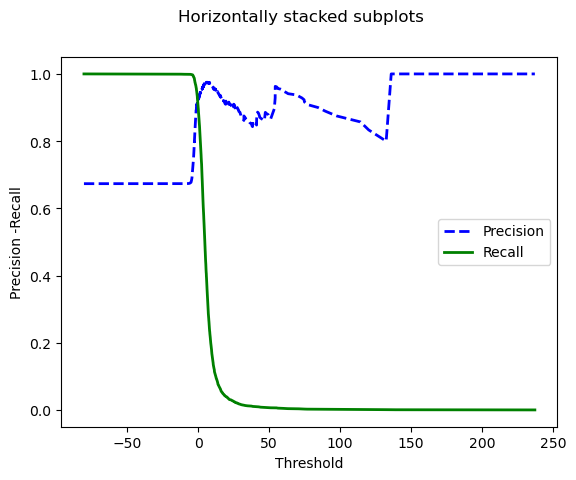

In [278]:
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
#threshold=10
fig, ax1 = plt.subplots(1, 1)
fig.suptitle('Horizontally stacked subplots')


ax1.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
ax1.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
#ax3.plot(precisions[:-1], recalls[:-1], "g-", label="Recall", linewidth=2)

#plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
#ax.plot3D(x, y, z, 'green')
# extra code – this section just beautifies and saves Figure 3–5
#idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
#plt.plot(thresholds[idx], precisions[idx], "bo")
#plt.plot(thresholds[idx], recalls[idx], "go")
#plt.axis([-50000, 50000, 0, 1])

ax1.set_xlabel('Threshold')
ax1.set_ylabel('Precision -Recall')
#ax2.set_xlabel('Threshold')
#ax2.set_ylabel('Recall')
#ax3.set_xlabel('Precision')
#ax3.set_ylabel('Recall')

ax1.legend(loc="center right")
#save_fig("precision_recall_vs_threshold_plot")
#plt.show()

In [279]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, y_scores)

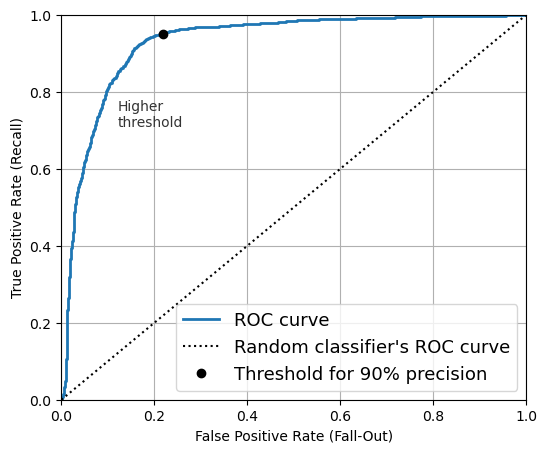

In [280]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# extra code – just beautifies and saves Figure 3–7

plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
#save_fig("roc_curve_plot")

plt.show()


In [281]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train, y_scores)

0.9309385651865806

### Feature Importance

<Axes: ylabel='Feature'>

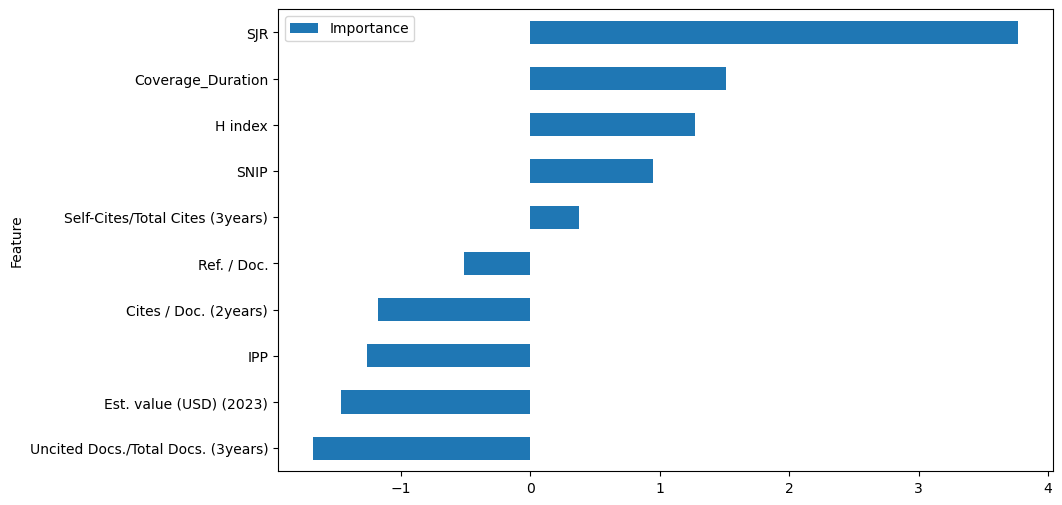

In [282]:
feature_importance = pd.DataFrame({'Feature': labeled_X.columns, 'Importance': sgd_class.coef_[0]})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6))

## Predict the Labels with the Trained Classifier

In [283]:
sgd_class.coef_

array([[ 3.76547436,  1.27544514, -1.2620822 ,  0.94460922, -1.46672887,
         0.37465963, -1.67905378, -1.18065735, -0.51389594,  1.51025514]])

In [284]:
# Testing:
test_predicts= sgd_class.predict_proba(X_test)
a, count=np.unique(test_predicts,return_counts=True, axis=0)

for i in count:
    if i>1:
        print(i)

7


In [285]:
TO_predict=df.drop(columns=["Title","Publisher", "Total Docs. (2023)","Total Docs. (3years)", "Total Refs.", "Total Cites (3years)", "Citable Docs. (3years)" ])
TO_predict=TO_predict[Labels.Labels.isna()]
TO_predict

,SJR,H index,IPP,SNIP,Est. value (USD) (2023),Self-Cites/Total Cites (3years),Uncited Docs./Total Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Coverage_Duration
0,106.094,223,508.896104,167.948451,1508428.0,0.000699,0.217742,385.46,91.91,76
1,37.044,42,57.923077,24.121591,114748.0,0.000000,0.076923,115.11,299.00,17
2,35.910,531,100.337931,19.301441,3549661.0,0.003250,0.360119,34.40,86.32,26
3,30.448,322,15.220588,9.636010,1383193.0,0.019391,0.036765,10.79,77.55,140
4,26.837,527,65.386076,11.500953,3155228.0,0.005563,0.376238,31.34,102.90,25
...,...,...,...,...,...,...,...,...,...,...
27085,0.100,5,0.021277,0.027996,385422.0,0.400000,0.942529,0.03,18.56,13
27091,0.100,9,0.043956,0.166054,382000.0,0.000000,0.949495,0.03,24.00,14
27098,0.100,3,0.193548,1.062923,208133.0,0.000000,0.870968,0.28,23.54,11
27099,0.100,1,0.021277,0.197872,235160.0,0.000000,0.970297,0.04,20.58,6


array([[ 7.22454180e+01,  2.98130827e+00,  9.94564570e+01, ...,
         9.46226259e+01,  1.81373598e+00,  2.66103777e+00],
       [ 2.49127692e+01, -1.44175956e-01,  1.09388550e+01, ...,
         2.79092138e+01,  9.78857873e+00, -3.99695619e-01],
       [ 2.41354307e+01,  8.29981181e+00,  1.92641005e+01, ...,
         7.99266304e+00,  1.59847030e+00,  6.71959154e-02],
       ...,
       [-4.11740282e-01, -7.14015622e-01, -4.21737917e-01, ...,
        -4.88712860e-01, -8.01414775e-01, -5.55326130e-01],
       [-4.11740282e-01, -8.52158571e-01, -4.26189470e-01, ...,
        -4.86245192e-01, -9.33115785e-01, -9.70340827e-01],
       [-4.11740282e-01, -8.34890702e-01, -4.22617721e-01, ...,
        -4.83777523e-01,  6.60004328e-01, -9.70340827e-01]])

In [286]:
NEW_Labels=sgd_class.predict(scaler.transform(TO_predict))

In [287]:
sgd_class.predict(scaler.transform(TO_predict))

array([1., 1., 1., ..., 0., 0., 0.])

In [288]:
np.where(NEW_Labels==0)

(array([  441,   802,  1153, ..., 18369, 18370, 18371], dtype=int64),)

In [201]:
Labels.Labels.isna().sum()

18372

In [202]:
np.where(NEW_Labels==0)[0]

array([  441,   802,  1638, ..., 18369, 18370, 18371], dtype=int64)

In [106]:
df.index 

RangeIndex(start=0, stop=27107, step=1)

In [203]:
np.where(NEW_Labels==0)

(array([  441,   802,  1638, ..., 18369, 18370, 18371], dtype=int64),)

In [289]:
sgd_class.predict_proba(scaler.transform(TO_predict))[np.where(NEW_Labels==0)]

array([[5.00392341e-01, 4.99607659e-01],
       [9.99999818e-01, 1.82108459e-07],
       [7.25674792e-01, 2.74325208e-01],
       ...,
       [8.89052339e-01, 1.10947661e-01],
       [9.73169829e-01, 2.68301706e-02],
       [9.63591264e-01, 3.64087362e-02]])

In [205]:
df[Labels.Labels.isna()].iloc[np.where(NEW_Labels==0)[0],:]

,Title,SJR,H index,IPP,SNIP,Total Docs. (2023),Total Docs. (3years),Total Refs.,Est. value (USD) (2023),Total Cites (3years),Self-Cites/Total Cites (3years),Uncited Docs./Total Docs. (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Coverage_Duration,Publisher
692,Journal of Bioresources and Bioproducts,2.880,42,19.934066,3.565044,38,89,2209,402732.0,1866,0.004287,0.022472,89,22.66,58.13,7,KeAi Communications Co.
1258,ACS Applied Materials and Interfaces,2.058,334,11.821372,2.752626,5441,17387,290446,108735081.0,156510,0.047773,0.039800,17365,8.43,53.38,17,American Chemical Society
2610,Physical Review B,1.345,517,3.425741,0.903379,4967,14922,292727,90391273.0,51166,0.313177,0.192467,14905,3.36,58.93,14,American Physical Society
3863,Frontiers in Oncology,1.066,156,3.741733,0.831176,5104,16239,252083,80540681.0,61472,0.050576,0.169592,15862,3.43,49.39,15,Frontiers Media SA
3864,Frontiers in Pharmacology,1.066,175,4.691946,0.999307,3461,11888,215691,57911326.0,56041,0.038454,0.134169,11465,4.32,62.32,16,Frontiers Media SA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27085,Svensk Teologisk Kvartalskrift,0.100,5,0.021277,0.027996,45,87,835,385422.0,5,0.400000,0.942529,79,0.03,18.56,13,Gleerup
27091,Terrain,0.100,9,0.043956,0.166054,29,99,696,382000.0,5,0.000000,0.949495,95,0.03,24.00,14,OpenEditions Journals
27098,University of Bucharest Review: Literary and C...,0.100,3,0.193548,1.062923,24,62,565,208133.0,12,0.000000,0.870968,62,0.28,23.54,11,Bucharest University Press
27099,Veredas,0.100,1,0.021277,0.197872,31,101,638,235160.0,3,0.000000,0.970297,97,0.04,20.58,6,International Association of Lusitanistas


In [290]:
Labeled_False=df[Labels.Labels.isna()].iloc[np.where(NEW_Labels==0)[0],:]#.sort_values("H index", ascending=False)
for ind in Labeled_False.index:
    #print(ind)
    Labels.iloc[ind,0]=0

In [291]:
#get back some of the Good ones
for ind in Labeled_False[(Labeled_False["SJR"]>1) | (Labeled_False["H index"] >70)].index:
    Labels.iloc[ind,0]=1

In [292]:
# Fill the Others with 1:
Labels.fillna(1,inplace=True)

## Export Files:

In [293]:
with open("Labels_2023_END.csv", "w") as file2:
    Labels.to_csv(file2, index=False,lineterminator='\n')

In [294]:
df["Labels"]=Labels.Labels

In [295]:
with open("Data_with_Labels.csv", "w") as file2:
    df.to_csv(file2, index=False,lineterminator='\n')

In [296]:
import joblib

joblib.dump(sgd_class, "my_FINAL_sgd_class.pkl")

['my_FINAL_sgd_class.pkl']

In [297]:
import joblib
scaler_filename = "Scaler.save"
joblib.dump(scaler, scaler_filename) 

['Scaler.save']

# ----- Additional: Steps needed to create the Labels_2023.csv (but for now just skip it and import the labels)

## Labeliing only Good-Bad without Bealls list (only about 4k values labeled with it)

In [6]:
label = [np.nan] * len(publishers)
good_pub = ["Springer", "Springer Nature", "Elsevier", "Taylor and Francis", 
            "American Mathematical Society", "Society for Industrial and Applied Mathematics Publications", "de Gruyter", "De Gruyter", 
            "American Institute of Mathematical Sciences", "European Mathematical Society Publishing House"]
bad_pub = ["Multidisciplinary Digital Publishing Institute", "Science and Information Organization", "Natural Sciences Publishing"]
for i in range(len(publishers)):
    for j in range(len(good_pub)):
        if good_pub[j] in publishers[i]:
            label[i] = 1
            
    for j in range(len(bad_pub)):
        if bad_pub[j] in publishers[i]:
            label[i] = 0
        
    #elif 29000 < i: # last 2k jpurnals are bad
    #    label[i] = 0
   # else:
    #    label[i] = np.nan

In [8]:
publishers[~np.isnan(label)]

5                  Elsevier B.V.
21               Springer Nature
29       Taylor and Francis Ltd.
37                  Elsevier Ltd
38                 Elsevier B.V.
                  ...           
26999     Elsevier Masson s.r.l.
27023     Elsevier Masson s.r.l.
27033    Taylor and Francis Ltd.
27073     Elsevier Masson s.r.l.
27102     Walter de Gruyter GmbH
Name: Publisher, Length: 6128, dtype: object

In [9]:
np.isnan(label).sum() # NOT LABELEDs

20979

## Bealls list (Predatory journals list)

### Preparing Publishers+ Journalist datasets (DO NOT RUN 2nd time, just take the LABEL_2023.csv)

#### Publishers (Do not run anymore) (Total BAD journal in my DB from Bealls list 324)

#### 1.  DO NOT RUN Anymore (use "_AFTER") Preparing the Bells list (some formatting)

In [ ]:
# Publishers
with open("Bealls list Publisher_AFTER Manual_2.txt", "r") as file:
    data=file.read().splitlines()
    for publisher in data:
        #unnceesary ( [
        bad_char=["(", "["]
        publisher=publisher.replace("&","&amp;")
        first=publisher.find(bad_char[0])
        second=publisher.find(bad_char[1])
            
        
        if (first>second and second==-1) or (second>first and first!=-1):
            good_publisher=publisher[:first].strip()

            
        elif (second>first and first==-1) or (first>second and second!=-1):
            good_publisher=publisher[:second].strip()
        else:
            
            good_publisher=publisher
        with open("Bealls list Publisher_2.txt","a") as fil1:
            fil1.write(good_publisher +"\n")

In [ ]:
"123" in "123(123)"

#### 2. AFTER MANUALLY EDITED Some Entries of Publishers

In [ ]:
with open("Bealls list Publisher_AFTER Manual.txt",  "r") as file1:
    bad_pub=file1.read().splitlines()
counter=0
to_delete=[]
for i in range(len(publishers)):
            
    for j in range(len(bad_pub)):
        if bad_pub[j] in publishers[i]:
            if df.iloc[i, 1]>0.7:
                to_delete.append(bad_pub[j])
            print(df.iloc[i, 1])
            print(publishers[i])
            print(bad_pub[j])
            print()
            counter+=1
            

print(counter)

In [ ]:
to_delete

#### Journals (Do not run anymore) (standalone)

In [ ]:
# Publishers
with open("Bealls list Journals.txt", "r") as file:
    data=file.read().splitlines()
    for publisher in data:
        #unnceesary ( [
        bad_char=["(", "["]
        #publisher=publisher.replace("&","&amp;")
        first=publisher.find(bad_char[0])
        second=publisher.find(bad_char[1])
            
        
        if (first>second and second==-1) or (second>first and first!=-1):
            good_publisher=publisher[:first].strip()

            
        elif (second>first and first==-1) or (first>second and second!=-1):
            good_publisher=publisher[:second].strip()
        else:
            
            good_publisher=publisher
        with open("Bealls list Journals_CLEAN.txt","a") as fil1:
            fil1.write(good_publisher +"\n")

In [ ]:
# search in DF
df.shape[0]

In [ ]:
count=0
lines=0
with open("Bealls list Journals_CLEAN.txt", "r") as file1:
    data=file1.read().splitlines()
    co1=0
    for line in df["Title"]:
    
        
        for j in data:
            if len(j.split(" "))==1:
                continue
            if j in line:
                count+=1
                print(df.iloc[co1, 1])
                print(line)
                print(j)
                print()
        co1+=1
print(count)

#### Label BAD-Good with the CLEAN Bealls data

In [10]:
with open("Bealls list Publisher_AFTER Manual.txt", "r") as file1:
    data=file1.read().splitlines()
    count=0
    for i in range(len(publishers)):
        for j in data:
            if j in publishers[i]:
                label[i] = 0
                count+=1

In [11]:
print(count)

256


In [12]:
with open("Bealls list Journals_CLEAN.txt", "r") as file1:
    data=file1.read().splitlines()
    count=0
    for i in range(len(publishers)):
        for j in data:
            if j in df["Title"][i]: #check for Title
                label[i] = 0
                count+=1

In [13]:
print(count)

104


In [14]:
np.isnan(label).sum()

20655

In [16]:
a=~np.isnan(label)
a.sum()

6452

In [ ]:
import csv

with open("Labels_2023.csv","w",newline='') as file1:
    write = csv.writer(file1)
    write.writerow(["Labels"])
    write.writerows([[i] for i in label])


## Plots

In [ ]:
train_plot.plot("SJR", "H index",kind="scatter")

In [ ]:
train_plot.plot("SJR", "SNIP",kind="scatter")

In [ ]:
train_plot.plot("SJR", "Cites / Doc. (2years)",kind="scatter")

In [ ]:
train_plot=pd.DataFrame(train_prep, columns=['SJR', 'H index', 'IPP', 'SNIP', 'Total Docs. (2023)',
       'Total Docs. (3years)', 'Total Refs.', 'Est. value (USD) (2023)',
       'Total Cites (3years)', 'Self-Cites/Total Cites (3years)',
       'Uncited Docs./Total Docs. (3years)', 'Citable Docs. (3years)',
       'Cites / Doc. (2years)', 'Ref. / Doc.', 'Coverage_Duration'])

In [ ]:
train_plot.plot("SNIP", "Coverage_Duration",kind="scatter")

In [ ]:
train_plot.plot("SJR", "Total Cites (3years)",kind="scatter")

In [ ]:
train_plot.plot("SJR", "H index",kind="scatter")

In [ ]:
train_plot.plot("SJR", "H index",kind="scatter")

In [ ]:
train_plot.plot("SJR", "H index",kind="scatter")

In [ ]:
train_plot.plot("SJR", "H index",kind="scatter")

In [ ]:
train_plot.plot("SJR", "H index",kind="scatter")

## Add more 0's based on DOAJ index + K-Means

> check DOAJ indexing (whether a journal is there AND check with K-Means, what would I rate as negative) 
Thus I combine Data from My Dataset + From what others find GOOD to label with 0

### DOAJ Indexing
https://beallslist.net/how-to-recognize-predatory-journals/  
https://doaj.org/

In [21]:
with open("journalcsv__doaj_20250501_1827_utf8.csv","r",encoding="utf-8") as file1:
    title=pd.read_csv(file1)["Journal title"]
def checkDOAJ(name):
    if title.str.contains(name).any():
        return True
    else:
        return False

### Trying to Add more 0's (Methods that didn't work in the end)
#### Test with Adding Countries column One Hot encoder for countries

In [ ]:
with open("DONE_scimagojr 2023.csv", "r", encoding="utf-8") as file2:
    scimago=pd.read_csv(file2)
    df1=pd.merge(df, scimago[["Title", "Country"]].drop_duplicates(subset=["Title"]), how="left", on="Title"

In [ ]:
train=df1.drop(columns=["Title","Publisher"])

In [ ]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

categor=train["Country"]
numer=train.drop(columns=["Country"])
scaler = MinMaxScaler()
scaled_X=scaler.fit_transform(numer)
encoder = OneHotEncoder()
encoded=encoder.fit_transform(categor.to_frame()).toarray()
all_data=np.concatenate((scaled_X,encoded),axis=1)

In [ ]:
len(encoded[0])

In [ ]:
len(all_data[0])

In [ ]:
all_data.size

In [ ]:
from sklearn.metrics import silhouette_score
start=100
end=110
step=10
kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(all_data)
                for k in range(start, end, step)]
silhouette_scores = [silhouette_score(train_prep, model.labels_)
                     for model in kmeans_per_k]



In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(range(start, end, step), silhouette_scores, "bo-")

plt.xlabel("$k$")
plt.ylabel("Silhouette score")
#plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()
#save_fig("silhouette_score_vs_k_plot")
plt.show()

#### K-Means Analysis (Analyze + Label BAD Data)

In [ ]:
#prepare Data needed:
train=df.drop(columns=["Title","Publisher"])

In [ ]:
from sklearn.preprocessing import MinMaxScaler
def preprocess(labeled_X):
    scaler = MinMaxScaler()
    scaled_X=scaler.fit_transform(labeled_X)
    return scaled_X

In [ ]:
train_prep=preprocess(train)

In [ ]:
train.columns

In [ ]:
np_train=np.array(train)

In [ ]:
from sklearn.cluster import KMeans
k = 2
kmeans = KMeans(n_clusters=k, random_state=42, tol=1e-10,n_init=40)
train_prep_X = kmeans.fit_transform(np_train)

##### Evauating Kmeans

In [ ]:
from sklearn.metrics import silhouette_score
start=2
end=20
step=1
kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(np_train)
                for k in range(start, end, step)]
silhouette_scores = [silhouette_score(train_prep, model.labels_)
                     for model in kmeans_per_k]



In [ ]:
silhouette_scores_1=silhouette_scores

In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(range(start, end, step), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
#plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()
#save_fig("silhouette_score_vs_k_plot")
plt.show()

In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(range(start, end, step), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
#plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()
#save_fig("silhouette_score_vs_k_plot")
plt.show()

In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(range(start, end, step), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
#plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()
#save_fig("silhouette_score_vs_k_plot")
plt.show()

In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(range(10, 100,10), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
#plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()
#save_fig("silhouette_score_vs_k_plot")
plt.show()

##### Labelling

In [ ]:
X_representative_data.iloc[0,:].to_frame().transpose()

In [ ]:
representative_indeces = train_prep_X.argmin(axis=0)
X_representative_data = df.iloc[representative_indeces,:]

In [ ]:
y_representative_data[1] is np.nan

In [ ]:
X_representative_data[np.isnan(y_representative_data)]

In [ ]:
index1=0
for index, row in X_representative_data[np.isnan(y_representative_data)].iterrows():
    while y_representative_data[index1] is not np.nan:
        index1+=1
    print("Left: ", np.isnan(y_representative_data).sum())
    
    display(row.to_frame().transpose())
    print(checkDOAJ(row.Title))
    inp=input("1/0: ")
    y_representative_data[index1]=int(inp)
    index1+=1 #for y_representative

In [ ]:
np.isnan(y_representative_data).sum()

In [ ]:
y_representative_data=[label[i] for i in representative_indeces]

In [ ]:
#populate labels
for i in range(len(representative_indeces)):
    label[representative_indeces[i]]=y_representative_data[i]

In [ ]:
np.isnan(y_representative_data).sum()

In [ ]:
len(X_representative_digits[:,8])

In [ ]:
indec={'SJR':0 , 'H index':1, 'IPP':2, 'SNIP':3, 'Total Docs. (2023)':4,
       'Total Docs. (3years)':5, 'Total Refs.':6, 'Est. value (USD) (2023)':7,
       'Total Cites (3years)':8, 'Self-Cites/Total Cites (3years)':9,
       'Uncited Docs./Total Docs. (3years)':10, 'Citable Docs. (3years)':11,
       'Cites / Doc. (2years)':12, 'Ref. / Doc.':13, 'Coverage_Duration':14}


In [ ]:
import matplotlib.pyplot as plt
string_x="SJR"
string_y="Self-Cites/Total Cites (3years)"
lo=plt.scatter(train_prep[:,indec[string_x]], train_prep[:,indec[string_y]],c=kmeans.labels_) 
plt.xlabel(string_x)
plt.ylabel(string_y)
plt.legend(handles=lo.legend_elements()[0], labels=["0","1"])

#### DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN()
dbscan.fit(train_prep)

In [ ]:
np.where(dbscan.labels_==-1)

#### PCA (does not help)

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=0.95)
result=pca.fit_transform(train_prep)

In [ ]:
pca.explained_variance_ratio_

In [ ]:
from sklearn.cluster import KMeans
k = 20
kmeans1 = KMeans(n_clusters=k, random_state=42, tol=1e-10,n_init=40)
result_X = kmeans1.fit_transform(result)

In [ ]:
kmeans1.inertia_

In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(range(start, end, step), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
#plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()
#save_fig("silhouette_score_vs_k_plot")
plt.show()